# Independent groups

This notebook implements NB15 from `steady-vault-plan-01.md`.  The parent is
frozen at NB12 P1+D1 and the NB14 E0 evidence policy, with equal member
weights, a 20% individual cap, a 5% provisional cap and a 20% aggregate
provisional sleeve.  It compares three grouping policies:

* **G0**: no grouping beyond the parent individual/evidence/TVL caps;
* **G1**: a verified-manager exposure cap of 25%; and
* **G2**: G1 plus complete-link weekly-return correlation clusters at 0.75,
  requiring at least eight paired weeks in the preceding 90 days.

Grouping is an allocation constraint, not an admission filter.  Missing or
unverified identity and dependence evidence remains eligible as a singleton
but is reported and receives the declared uncertainty treatment.  No
follower, popularity or forward outcome data is used.  Marks are causal
forward-filled NAV observations for valuation only; there are no invented
fees, slippage or liquidation assumptions.


In [1]:
from pathlib import Path
import json
import math
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd() / "scratchpad/hyperliquid-ic" if (Path.cwd() / "scratchpad/hyperliquid-ic").exists() else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
REWRITE = PROJECT_DIR / "_artifacts-rewrite"
NB12 = PROJECT_DIR / "_artifacts-downside-stress"
NB14 = PROJECT_DIR / "_artifacts-young-sparse"
OUT = PROJECT_DIR / "_artifacts-independent-groups"
OUT.mkdir(exist_ok=True)

PERIODS = {
    "hyper_ai": (pd.Timestamp("2026-01-01"), pd.Timestamp("2026-07-08")),
    "full": (pd.Timestamp("2025-09-13"), pd.Timestamp("2026-09-12")),
}
INITIAL_CASH = 150_000.0
TARGET_DEPLOYMENT = 0.98
INDIVIDUAL_CAP = 0.20
PROVISIONAL_CAP = 0.05
PROVISIONAL_SLEEVE = 0.20
TVL_CAP = 0.33
GROUP_CAP = 0.25
CORRELATION_THRESHOLD = 0.75
MIN_PAIRED_WEEKS = 8
CORRELATION_DAYS = 90
EXECUTION_EVERY_DAYS = 2
STRATWISE = "0x0ff219ac20596b457558341bc410bc7a08a1394c"

OBS = pd.read_parquet(REWRITE / "observations.parquet")
OBS["address"] = OBS.address.astype(str).str.lower()
OBS["timestamp"] = pd.to_datetime(OBS.timestamp)
OBS = OBS[OBS.is_fresh & OBS.share_price.gt(0)].sort_values(["address", "timestamp"])
METADATA = pd.read_csv(REWRITE / "vault-metadata.csv")
METADATA["address"] = METADATA.address.astype(str).str.lower()
METADATA = METADATA.drop_duplicates("address").set_index("address")

def load_parent(universe_name):
    # NB14 writes E0 targets at execution dates.  These rows are the frozen
    # parent allocation inputs and contain no forward returns.
    target = pd.read_parquet(NB14 / f"targets-{universe_name}-E0-full.parquet")
    target["date"] = pd.to_datetime(target.date).dt.normalize()
    target["address"] = target.address.astype(str).str.lower()
    target = target[target.date.between(PERIODS["full"][0], PERIODS["full"][1])].copy()
    if target.duplicated(["date", "address"]).any():
        raise AssertionError(f"duplicate E0 target rows in {universe_name}")
    return target

PARENTS = {name: load_parent(name) for name in ("full_panel", "a0b_allowlist")}
print({name: (len(frame), int(frame.date.nunique()), int(frame.address.nunique())) for name, frame in PARENTS.items()})
print({"observations": OBS.shape, "metadata": METADATA.shape, "stratwise_observations": int((OBS.address == STRATWISE).sum())})


{'full_panel': (1437, 113, 105), 'a0b_allowlist': (1095, 112, 69)}
{'observations': (487738, 9), 'metadata': (4148, 92), 'stratwise_observations': 355}


## Identity and dependence inputs

The metadata mapping uses only an explicit non-empty `curator_name` value.  A
vault without that verified field is assigned a
deterministic singleton; a name prefix or social relationship never creates a
group.  The metadata snapshot is retained in the manifest.  Weekly returns
are built from observed endpoint marks up to the decision date.  A pair can
merge only when its pairwise estimate has at least eight observations and
correlation at least 0.75.  The complete-link pass checks every pair in a
cluster, so a transitive chain cannot create an unsupported group.


In [2]:
def clean_identity(value):
    if pd.isna(value) or not str(value).strip():
        return None
    text = re.sub(r"\s+", " ", str(value).strip()).casefold()
    return text or None


def verified_manager(address):
    if address not in METADATA.index:
        return None, "unknown"
    row = METADATA.loc[address]
    if "curator_name" in row.index:
        value = clean_identity(row["curator_name"])
        if value is not None:
            return value, "curator_name"
    return None, "unknown"


identity_rows = []
for address in sorted(set(OBS.address.unique()) | {a for frame in PARENTS.values() for a in frame.address.unique()}):
    manager, source = verified_manager(address)
    identity_rows.append({"address": address, "manager_id": manager, "identity_source": source, "identity_verified": manager is not None})
IDENTITY = pd.DataFrame(identity_rows)
IDENTITY.to_csv(OUT / "identity-mapping.csv", index=False)

weekly_marks = OBS.assign(week=OBS.timestamp.dt.to_period("W-SUN").dt.end_time.dt.normalize()).groupby(["week", "address"]).last().share_price.unstack("address")
weekly_returns = weekly_marks.sort_index().pct_change(fill_method=None)

btc_reference = pd.read_parquet(REWRITE / "btc-reference.parquet")
btc_reference.index = pd.to_datetime(btc_reference.index).tz_localize(None)
btc_weekly_returns = btc_reference["close"].resample("W-SUN").last().pct_change(fill_method=None)


def btc_beta(address, decision_date):
    if address not in weekly_returns.columns:
        return np.nan, 0
    lower = decision_date - pd.Timedelta(days=CORRELATION_DAYS)
    source = pd.concat([weekly_returns[address], btc_weekly_returns.rename("btc")], axis=1)
    source = source.loc[(source.index <= decision_date) & (source.index > lower)].dropna()
    if len(source) < MIN_PAIRED_WEEKS or source["btc"].var(ddof=1) <= 0:
        return np.nan, int(len(source))
    return float(source[address].cov(source["btc"]) / source["btc"].var(ddof=1)), int(len(source))


def pairwise_correlations(addresses, decision_date):
    addresses = sorted(set(addresses))
    lower = decision_date - pd.Timedelta(days=CORRELATION_DAYS)
    source = weekly_returns.loc[(weekly_returns.index <= decision_date) & (weekly_returns.index > lower)].reindex(columns=addresses)
    result = {}
    for index, left in enumerate(addresses):
        for right in addresses[index + 1:]:
            pair = source[[left, right]].dropna()
            count = len(pair)
            corr = float(pair[left].corr(pair[right])) if count >= 2 else np.nan
            result[(left, right)] = {"paired_weeks": count, "correlation": corr, "eligible": bool(count >= MIN_PAIRED_WEEKS and pd.notna(corr) and corr >= CORRELATION_THRESHOLD)}
    return result


def complete_link_clusters(addresses, pair_stats):
    clusters = []
    for address in sorted(set(addresses)):
        placed = False
        for cluster in clusters:
            if all(pair_stats.get(tuple(sorted((address, other))), {"eligible": False})["eligible"] for other in cluster):
                cluster.append(address)
                placed = True
                break
        if not placed:
            clusters.append([address])
    return {address: f"corr-{number:03d}" for number, cluster in enumerate(clusters, 1) for address in cluster}, clusters


def identity_groups(addresses):
    groups = {}
    for address in sorted(set(addresses)):
        manager, _ = verified_manager(address)
        groups[address] = f"manager:{manager}" if manager is not None else f"singleton:{address}"
    return groups


def group_assignments(addresses, date):
    addresses = sorted(set(addresses))
    managers = identity_groups(addresses)
    pair_stats = pairwise_correlations(addresses, date)
    corr_ids, corr_clusters = complete_link_clusters(addresses, pair_stats)
    return managers, corr_ids, pair_stats, corr_clusters


group_diagnostics = []
for universe_name, parent in PARENTS.items():
    for date, day in parent.groupby("date", sort=True):
        addresses = day.loc[day.accepted_dollars.gt(0), "address"].tolist()
        manager_map, corr_map, pair_stats, corr_clusters = group_assignments(addresses, date)
        for address in addresses:
            manager, source = verified_manager(address)
            pair = [value for key, value in pair_stats.items() if address in key]
            beta, beta_pairs = btc_beta(address, date)
            group_diagnostics.append({"universe": universe_name, "date": date, "address": address, "manager_group": manager_map[address], "corr_group": corr_map[address], "identity_source": source, "identity_unknown": manager is None, "correlation_pairs": len(pair), "correlation_measured_pairs": sum(item["paired_weeks"] >= MIN_PAIRED_WEEKS for item in pair), "correlation_eligible_pairs": sum(item["eligible"] for item in pair), "corr_cluster_size": len(next(cluster for cluster in corr_clusters if address in cluster)), "btc_beta": beta, "btc_beta_pairs": beta_pairs})
GROUP_DIAGNOSTICS = pd.DataFrame(group_diagnostics)
GROUP_DIAGNOSTICS.to_parquet(OUT / "group-diagnostics.parquet", index=False)
display(GROUP_DIAGNOSTICS.head())


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,universe,date,address,manager_group,corr_group,identity_source,identity_unknown,correlation_pairs,correlation_measured_pairs,correlation_eligible_pairs,corr_cluster_size,btc_beta,btc_beta_pairs
0,full_panel,2026-01-31,0x2ed5c4484ea3ff8b57d5f2fb152a40d9f2b68308,manager:hyperliquid,corr-001,curator_name,False,1,1,0,1,-3.133871,9
1,full_panel,2026-01-31,0x5e177e5e39c0f4e421f5865a6d8beed8d921cb70,manager:hyperliquid,corr-002,curator_name,False,1,1,0,1,-0.557471,9
2,full_panel,2026-02-02,0x5e177e5e39c0f4e421f5865a6d8beed8d921cb70,manager:hyperliquid,corr-001,curator_name,False,4,4,0,1,-0.236003,10
3,full_panel,2026-02-02,0x61b1cf5c2d7c4bf6d5db14f36651b2242e7cba0a,singleton:0x61b1cf5c2d7c4bf6d5db14f36651b2242e...,corr-002,unknown,True,4,4,0,1,-0.260010,13
4,full_panel,2026-02-02,0x6ee75f1da817dccc144498b8a958d1199ae040d3,singleton:0x6ee75f1da817dccc144498b8a958d1199a...,corr-003,unknown,True,4,4,0,1,-1.049249,13


## Allocation replay

G0 uses the accepted NB14 E0 dollars as a no-op parent control.  G1 and G2
start from equal budgets across the relevant groups, equal member weights,
the E0 evidence cap and the existing TVL cap.  Group caps are then applied
without final redistribution, so the effect appears as cash.  In G2 the
complete-link correlation group is the budget group and the verified-manager
cap is applied independently; this enforces both constraints.  Unknown
dependence remains a singleton with an additional 5% uncertainty cap in G2.
The singleton sensitivity removes only this extra cap and does not merge
unknown names.


In [3]:
def build_daily_marks(observations, dates):
    marks = observations.assign(calendar_date=observations.timestamp.dt.normalize()).groupby(["calendar_date", "address"]).share_price.last().unstack("address")
    index = marks.index.union(dates).sort_values()
    return marks.reindex(index).sort_index().ffill().reindex(dates)


def finite(value):
    return pd.notna(value) and np.isfinite(float(value))


def allocations(day, equity, arm, date, parent_name, singleton_sensitivity=False):
    # Keep all parent-selected rows in the denominator.  A zero accepted
    # dollar row means that the parent had no usable mark at that decision;
    # dropping it would silently increase every other target weight.
    day = day.copy()
    if day.empty:
        return day.assign(requested_dollars=pd.Series(dtype=float), accepted_dollars=pd.Series(dtype=float))
    addresses = day.address.tolist()
    manager_map, corr_map, pair_stats, corr_clusters = group_assignments(addresses, date)
    group_map = {address: manager_map[address] if arm == "G1" else (corr_map[address] if arm == "G2" else f"address:{address}") for address in addresses}
    group_sizes = pd.Series(group_map).value_counts().to_dict()
    group_budget = TARGET_DEPLOYMENT / max(len(group_sizes), 1)
    requested_weight = {address: group_budget / group_sizes[group_map[address]] for address in addresses}
    rows = []
    for item in day.itertuples(index=False):
        address = item.address
        manager = manager_map[address]
        manager_known = not manager.startswith("singleton:")
        corr_group = corr_map[address]
        # E0's provisional cap is part of the frozen parent.  For G2,
        # unknown dependence has an extra uncertainty cap, without becoming
        # an admission veto.
        evidence_cap = float(item.evidence_cap_weight) if finite(item.evidence_cap_weight) else INDIVIDUAL_CAP
        # A singleton with enough paired weeks but low correlation is measured
        # and should remain an ordinary singleton.  Only a singleton without
        # any pair meeting the evidence threshold has unknown dependence.
        measured_dependence = any(v["paired_weeks"] >= MIN_PAIRED_WEEKS for k, v in pair_stats.items() if address in k)
        unknown_dependence = corr_group.startswith("corr-") and len(next(cluster for cluster in corr_clusters if address in cluster)) == 1 and not measured_dependence
        uncertainty_cap = PROVISIONAL_CAP if arm == "G2" and unknown_dependence and not singleton_sensitivity else INDIVIDUAL_CAP
        requested = equity * requested_weight[address]
        cap_weight = min(INDIVIDUAL_CAP, evidence_cap, uncertainty_cap)
        tvl = float(item.tvl_current) if finite(item.tvl_current) else 0.0
        cap_dollars = min(equity * cap_weight, max(tvl, 0.0) * TVL_CAP)
        accepted = min(max(requested, 0.0), max(cap_dollars, 0.0)) if arm != "G0" or float(item.accepted_dollars) > 0 else 0.0
        rows.append({"date": date, "address": address, "parent_accepted_dollars": float(item.accepted_dollars), "requested_weight": requested_weight[address], "requested_dollars": requested, "accepted_dollars": accepted, "cap_dollars": cap_dollars, "evidence_cap_weight": evidence_cap, "uncertainty_cap_weight": uncertainty_cap, "unknown_dependence": unknown_dependence, "provisional": bool(item.provisional), "evidence_reason": item.evidence_reason, "tvl_current": item.tvl_current, "manager_group": manager, "corr_group": corr_group, "manager_known": manager_known, "identity_source": verified_manager(address)[1], "corr_cluster_size": len(next(cluster for cluster in corr_clusters if address in cluster)), "correlation_pairs": sum(1 for key in pair_stats if address in key), "correlation_eligible_pairs": sum(1 for key, value in pair_stats.items() if address in key and value["eligible"]), "universe": parent_name, "arm": arm})
    output = pd.DataFrame(rows)
    provisional_total = output.loc[output.provisional, "accepted_dollars"].sum()
    provisional_cap_dollars = equity * PROVISIONAL_SLEEVE
    if provisional_total > provisional_cap_dollars > 0:
        output.loc[output.provisional, "accepted_dollars"] *= provisional_cap_dollars / provisional_total
        output["aggregate_provisional_cap_binding"] = output.provisional
    else:
        output["aggregate_provisional_cap_binding"] = False
    for group_column in (["manager_group"] if arm == "G1" else (["manager_group", "corr_group"] if arm == "G2" else [])):
        for _, group in output.groupby(group_column, dropna=False):
            total = group.accepted_dollars.sum()
            cap = equity * GROUP_CAP
            if total > cap > 0:
                factor = cap / total
                output.loc[group.index, "accepted_dollars"] *= factor
                output.loc[group.index, f"{group_column}_cap_binding"] = True
            else:
                output.loc[group.index, f"{group_column}_cap_binding"] = False
    output["individual_cap_binding"] = output.accepted_dollars + 1e-8 < output.requested_dollars
    output["accepted_weight"] = output.accepted_dollars / equity if equity else np.nan
    return output


def replay(parent, start, end, universe_name, arm, singleton_sensitivity=False):
    dates = pd.date_range(start, end, freq="D")
    marks = build_daily_marks(OBS, dates)
    execution_dates = set(dates[::EXECUTION_EVERY_DAYS])
    parent = parent[parent.date.between(start, end)]
    cash, units, last_prices = INITIAL_CASH, {}, {}
    curve_rows, target_rows = [], []
    for date in dates:
        for address, price in marks.loc[date].dropna().items():
            last_prices[address] = float(price)
        marked = {address: quantity * last_prices[address] for address, quantity in units.items() if address in last_prices}
        equity = cash + sum(marked.values())
        target = dict(marked)
        allocation = pd.DataFrame()
        turnover = 0.0
        if date in execution_dates:
            day = parent[parent.date.eq(date)].copy()
            allocation = allocations(day, equity, arm, date, universe_name, singleton_sensitivity=singleton_sensitivity)
            target = {item.address: float(item.accepted_dollars) for item in allocation.itertuples(index=False) if item.accepted_dollars > 0 and item.address in last_prices}
            cash = max(equity - sum(target.values()), 0.0)
            turnover = float(sum(abs(target.get(address, 0.0) - marked.get(address, 0.0)) for address in set(target) | set(marked)))
            units = {address: value / last_prices[address] for address, value in target.items() if value > 0 and address in last_prices}
            equity = cash + sum(value for address, value in target.items() if address in last_prices)
            if not allocation.empty:
                target_rows.extend(allocation.to_dict(orient="records"))
        invested = max(equity - cash, 0.0)
        weights = pd.Series({address: value / invested for address, value in target.items()}) if invested > 0 else pd.Series(dtype=float)
        manager_weights = {}
        corr_weights = {}
        if not allocation.empty and invested > 0:
            for key in ("manager_group", "corr_group"):
                if key in allocation:
                    values = allocation.groupby(key).accepted_dollars.sum() / invested
                    for group, value in values.items():
                        (manager_weights if key == "manager_group" else corr_weights)[group] = float(value)
        curve_rows.append({"date": date, "equity": equity, "cash": cash, "cash_fraction": cash / equity if equity else np.nan, "invested": invested, "n_positions": len(target), "effective_positions": float(1 / weights.pow(2).sum()) if len(weights) and weights.pow(2).sum() > 0 else 0.0, "max_position_weight": float(weights.max()) if len(weights) else 0.0, "max_manager_weight": max(manager_weights.values(), default=0.0), "max_corr_group_weight": max(corr_weights.values(), default=0.0), "turnover": turnover, "execution_date": date in execution_dates, "unknown_identity_count": int((allocation.manager_known == False).sum()) if not allocation.empty else 0, "unmatched_corr_count": int((allocation.correlation_eligible_pairs == 0).sum()) if not allocation.empty else 0, "universe": universe_name, "arm": arm, "singleton_sensitivity": singleton_sensitivity})
    curve = pd.DataFrame(curve_rows)
    curve["return"] = curve.equity.pct_change()
    curve["drawdown"] = curve.equity / curve.equity.cummax() - 1
    return curve, pd.DataFrame(target_rows)


def weekly_curve(curve):
    output = curve.assign(week=curve.date.dt.to_period("W-SUN").dt.end_time.dt.normalize()).sort_values("date").groupby("week", as_index=False).last()
    output["return"] = output.equity.pct_change()
    output["drawdown"] = output.equity / output.equity.cummax() - 1
    return output


def metrics(curve, annualisation):
    returns = curve["return"].dropna()
    std = returns.std(ddof=1)
    span_days = max((curve.date.iloc[-1] - curve.date.iloc[0]).days, 1)
    return {"start": curve.date.iloc[0], "end": curve.date.iloc[-1], "final_equity": float(curve.equity.iloc[-1]), "cagr": float((curve.equity.iloc[-1] / curve.equity.iloc[0]) ** (365 / span_days) - 1), "volatility": float(std * math.sqrt(annualisation)) if finite(std) else np.nan, "sharpe": float(returns.mean() / std * math.sqrt(annualisation)) if finite(std) and std > 0 else np.nan, "max_drawdown": float(curve.drawdown.min()), "ulcer": float(np.sqrt(np.mean(curve.drawdown.pow(2)))), "mean_cash_fraction": float(curve.cash_fraction.mean()), "mean_effective_positions": float(curve.effective_positions.mean()), "max_manager_weight": float(curve.max_manager_weight.max()), "max_corr_group_weight": float(curve.max_corr_group_weight.max()), "turnover": float(curve.turnover.sum())}


## Backtests and diagnostics

Daily equity is replayed over the two cold-start periods.  Weekly metrics are
sampled from the completed daily curve and do not feed allocation decisions.
The G0 path is checked against the NB14 E0 parent path; a mismatch is a
data/accounting failure rather than a strategy result.  The singleton
sensitivity removes only the extra G2 unknown-dependence cap, so its cost is
visible without silently treating unknown correlation as independence.


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/moo/code/getting-started/.venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


...

,universe,period,rows,max_abs_equity_error,status
0,full_panel,hyper_ai,189,0.0,pass
1,full_panel,full,365,0.0,pass
2,a0b_allowlist,hyper_ai,189,0.0,pass
3,a0b_allowlist,full,365,0.0,pass


,universe,rows,addresses,unknown_identity_rows,corr_pairs,corr_eligible_pairs,multi_member_corr_rows,measured_singleton_rows,unknown_dependence_singleton_rows
0,a0b_allowlist,1095,69,1058,11204,460,260,747,88
1,full_panel,1437,105,1365,18748,648,379,949,109


,universe,minimum_paired_weeks,eligible_pairs
0,a0b_allowlist,4,3.000000
1,a0b_allowlist,8,2.053571
2,a0b_allowlist,12,1.383929
3,full_panel,4,4.300885
4,full_panel,8,2.867257
5,full_panel,12,2.150442


,universe,joint_loss_fraction
0,a0b_allowlist,0.635302
1,full_panel,0.759757


,universe,date,address,manager_group,corr_group,identity_source,identity_unknown,correlation_pairs,correlation_measured_pairs,correlation_eligible_pairs,corr_cluster_size,btc_beta,btc_beta_pairs
2485,a0b_allowlist,2026-09-04,0x0ff219ac20596b457558341bc410bc7a08a1394c,singleton:0x0ff219ac20596b457558341bc410bc7a08...,corr-001,unknown,True,9,0,0,1,NaN,6
2495,a0b_allowlist,2026-09-06,0x0ff219ac20596b457558341bc410bc7a08a1394c,singleton:0x0ff219ac20596b457558341bc410bc7a08...,corr-001,unknown,True,10,0,0,1,NaN,7
2506,a0b_allowlist,2026-09-08,0x0ff219ac20596b457558341bc410bc7a08a1394c,singleton:0x0ff219ac20596b457558341bc410bc7a08...,corr-001,unknown,True,8,0,0,1,NaN,7
2516,a0b_allowlist,2026-09-10,0x0ff219ac20596b457558341bc410bc7a08a1394c,singleton:0x0ff219ac20596b457558341bc410bc7a08...,corr-002,unknown,True,9,0,0,1,NaN,7
2526,a0b_allowlist,2026-09-12,0x0ff219ac20596b457558341bc410bc7a08a1394c,singleton:0x0ff219ac20596b457558341bc410bc7a08...,corr-002,unknown,True,6,0,0,1,NaN,7


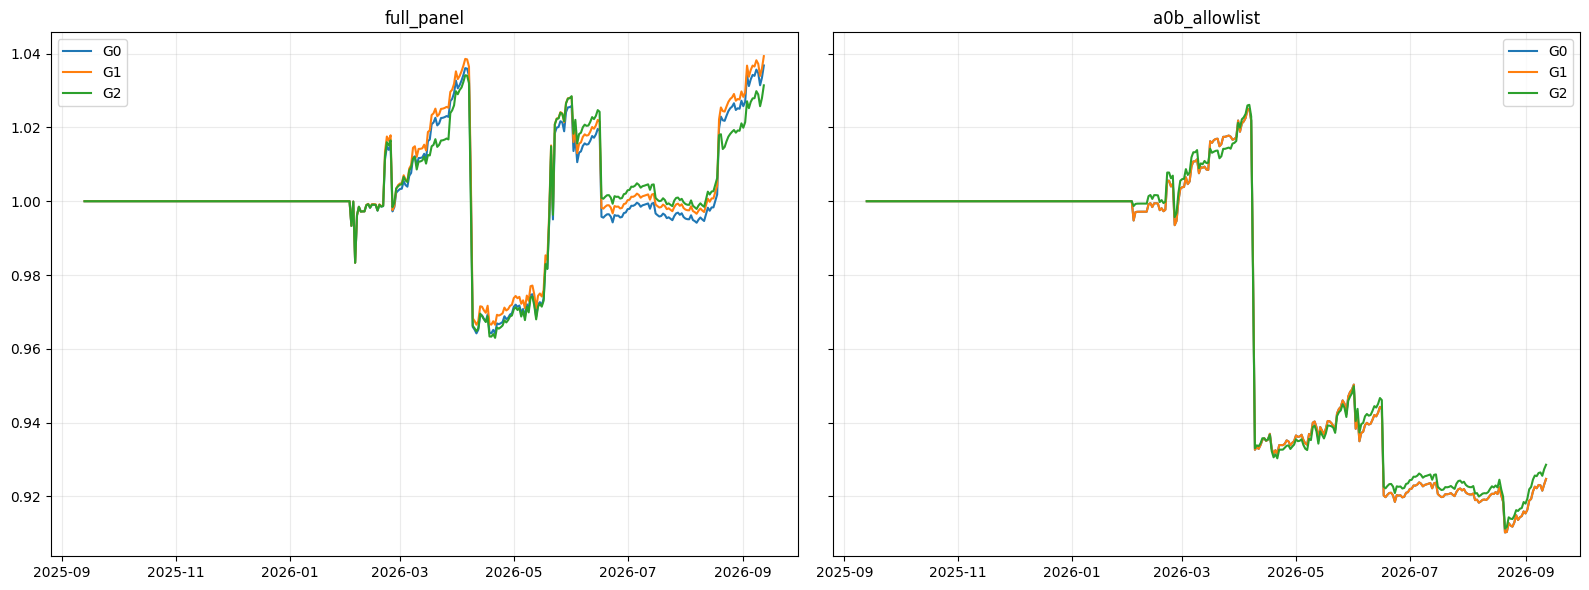

In [4]:
ARMS = ("G0", "G1", "G2")
CURVES, TARGETS, METRICS = {}, {}, []
for universe_name, parent in PARENTS.items():
    for arm in ARMS:
        for period_name, (start, end) in PERIODS.items():
            curve, targets = replay(parent, start, end, universe_name, arm)
            CURVES[(universe_name, arm, period_name)] = curve
            TARGETS[(universe_name, arm, period_name)] = targets
            curve.to_parquet(OUT / f"equity-{universe_name}-{arm}-{period_name}.parquet", index=False)
            targets.to_parquet(OUT / f"targets-{universe_name}-{arm}-{period_name}.parquet", index=False)
            for clock, measured, annualisation in [("daily", curve, 365.0), ("weekly", weekly_curve(curve), 52.0)]:
                METRICS.append({"universe": universe_name, "arm": arm, "period": period_name, "clock": clock, "singleton_sensitivity": False, **metrics(measured, annualisation)})
            if arm == "G2":
                sensitivity_curve, sensitivity_targets = replay(parent, start, end, universe_name, arm, singleton_sensitivity=True)
                CURVES[(universe_name, "G2_singleton_sensitivity", period_name)] = sensitivity_curve
                sensitivity_targets.to_parquet(OUT / f"targets-{universe_name}-G2-singleton-sensitivity-{period_name}.parquet", index=False)
                sensitivity_curve.to_parquet(OUT / f"equity-{universe_name}-G2-singleton-sensitivity-{period_name}.parquet", index=False)
                METRICS.append({"universe": universe_name, "arm": "G2_singleton_sensitivity", "period": period_name, "clock": "daily", "singleton_sensitivity": True, **metrics(sensitivity_curve, 365.0)})
metrics_table = pd.DataFrame(METRICS)
metrics_table.to_csv(OUT / "backtest-metrics.csv", index=False)
display(metrics_table.round(4))

parity_rows = []
for universe_name in PARENTS:
    for period_name, (start, end) in PERIODS.items():
        actual = CURVES[(universe_name, "G0", period_name)]
        reference = pd.read_parquet(NB14 / f"equity-{universe_name}-E0-{period_name}.parquet")
        reference["date"] = pd.to_datetime(reference.date)
        common = actual.merge(reference[["date", "equity"]], on="date", suffixes=("", "_parent"))
        error = float(np.max(np.abs(common.equity - common.equity_parent))) if len(common) else np.nan
        parity_rows.append({"universe": universe_name, "period": period_name, "rows": len(common), "max_abs_equity_error": error, "status": "pass" if len(common) and error < 1e-6 else "fail"})
parity = pd.DataFrame(parity_rows)
parity.to_csv(OUT / "g0-nb14-e0-parity.csv", index=False)
display(parity)
if not (parity.status == "pass").all():
    raise AssertionError("G0 does not reproduce the NB14 E0 parent curve")

coverage = GROUP_DIAGNOSTICS.groupby("universe").agg(rows=("address", "size"), addresses=("address", "nunique"), unknown_identity_rows=("identity_unknown", "sum"), corr_pairs=("correlation_pairs", "sum"), corr_eligible_pairs=("correlation_eligible_pairs", "sum"), multi_member_corr_rows=("corr_cluster_size", lambda x: int((x > 1).sum()))).reset_index()
coverage["measured_singleton_rows"] = GROUP_DIAGNOSTICS.assign(measured_singleton=GROUP_DIAGNOSTICS.corr_cluster_size.eq(1) & GROUP_DIAGNOSTICS.correlation_measured_pairs.gt(0)).groupby("universe").measured_singleton.sum().reindex(coverage.universe).to_numpy()
coverage["unknown_dependence_singleton_rows"] = GROUP_DIAGNOSTICS.assign(unknown_dependence_singleton=GROUP_DIAGNOSTICS.corr_cluster_size.eq(1) & GROUP_DIAGNOSTICS.correlation_measured_pairs.eq(0)).groupby("universe").unknown_dependence_singleton.sum().reindex(coverage.universe).to_numpy()
coverage.to_csv(OUT / "grouping-coverage.csv", index=False)
display(coverage)

# Dependence is a diagnostic, not an admission gate.  Recompute only the
# grouping evidence at nearby minimum-pair thresholds so the 8-week choice is
# visible without rerunning the portfolio arms.
corr_sensitivity_rows = []
for universe_name, parent in PARENTS.items():
    for date, day in parent.groupby("date", sort=True):
        addresses = day.loc[day.accepted_dollars.gt(0), "address"].tolist()
        lower = date - pd.Timedelta(days=CORRELATION_DAYS)
        source = weekly_returns.loc[(weekly_returns.index <= date) & (weekly_returns.index > lower)].reindex(columns=addresses)
        for minimum_weeks in (4, MIN_PAIRED_WEEKS, 12):
            eligible_pairs = 0
            for index, left in enumerate(addresses):
                for right in addresses[index + 1:]:
                    pair = source[[left, right]].dropna()
                    if len(pair) >= minimum_weeks and finite(pair[left].corr(pair[right])) and pair[left].corr(pair[right]) >= CORRELATION_THRESHOLD:
                        eligible_pairs += 1
            corr_sensitivity_rows.append({"universe": universe_name, "date": date, "minimum_paired_weeks": minimum_weeks, "eligible_pairs": eligible_pairs, "candidate_pairs": len(addresses) * max(len(addresses) - 1, 0) // 2})
corr_sensitivity = pd.DataFrame(corr_sensitivity_rows)
corr_sensitivity.to_csv(OUT / "correlation-threshold-sensitivity.csv", index=False)
display(corr_sensitivity.groupby(["universe", "minimum_paired_weeks"], as_index=False).eligible_pairs.mean())

# Joint-negative-week frequency is reported for the accepted parent basket;
# it is not used to create a group or change admission.
joint_loss_rows = []
for universe_name, parent in PARENTS.items():
    for date, day in parent.groupby("date", sort=True):
        addresses = day.loc[day.accepted_dollars.gt(0), "address"].tolist()
        lower = date - pd.Timedelta(days=CORRELATION_DAYS)
        source = weekly_returns.loc[(weekly_returns.index <= date) & (weekly_returns.index > lower)].reindex(columns=addresses)
        observed = source.dropna(how="all")
        loss_count = observed.lt(0).sum(axis=1)
        joint_loss_rows.append({"universe": universe_name, "date": date, "weeks": len(observed), "weeks_with_two_or_more_losses": int((loss_count >= 2).sum()), "joint_loss_fraction": float((loss_count >= 2).mean()) if len(observed) else np.nan, "all_names_loss_fraction": float((loss_count == len(addresses)).mean()) if len(observed) and addresses else np.nan})
joint_losses = pd.DataFrame(joint_loss_rows)
joint_losses.to_csv(OUT / "joint-loss-diagnostics.csv", index=False)
display(joint_losses.groupby("universe", as_index=False).joint_loss_fraction.mean())

stratwise_diag = GROUP_DIAGNOSTICS[GROUP_DIAGNOSTICS.address.eq(STRATWISE)].copy()
stratwise_diag.to_csv(OUT / "stratwise-group-diagnostics.csv", index=False)
display(stratwise_diag.tail())

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for axis, universe_name in zip(axes, PARENTS):
    for arm in ARMS:
        curve = CURVES[(universe_name, arm, "full")]
        axis.plot(curve.date, curve.equity / curve.equity.iloc[0], label=arm)
    axis.set_title(universe_name)
    axis.grid(alpha=.25)
    axis.legend()
fig.tight_layout()
fig.savefig(OUT / "independent-groups-equity-curves.png", dpi=130)
plt.show()


## Interpretation and limitations

The group arms do not claim independent strategy risk.  They measure whether
manager or observed-return dependence constraints change concentration,
cash and the Sharpe/CAGR frontier under the same P1+D1/E0 parent.  A lack of
eight paired weeks is an unknown dependence result, not evidence of low
correlation.  Correlation and BTC beta are diagnostics only.  The later
validation notebook must use a frozen recipe and include full-universe and
one-observation-delay sensitivities before any prospective shadow run.


In [5]:
report = {
    "notebook": "15-research-independent-groups.ipynb",
    "parent": "NB12 P1+D1 and NB14 E0 frozen parent",
    "arms": list(ARMS),
    "periods": {name: [str(start.date()), str(end.date())] for name, (start, end) in PERIODS.items()},
    "starting_cash": INITIAL_CASH,
    "execution_every_days": EXECUTION_EVERY_DAYS,
    "group_cap": GROUP_CAP,
    "individual_cap": INDIVIDUAL_CAP,
    "provisional_cap": PROVISIONAL_CAP,
    "correlation": {"threshold": CORRELATION_THRESHOLD, "minimum_paired_weeks": MIN_PAIRED_WEEKS, "lookback_days": CORRELATION_DAYS, "algorithm": "deterministic complete-link"},
    "identity": "explicit curator_name only; unknown addresses are singleton groups",
    "fees": "none added; observable NAV share prices are accounting input",
    "marks": "fresh raw observations forward-filled for valuation only",
    "parity": parity.to_dict(orient="records"),
    "metrics": metrics_table.to_dict(orient="records"),
    "coverage": coverage.to_dict(orient="records"),
    "correlation_threshold_sensitivity": corr_sensitivity.groupby("minimum_paired_weeks").eligible_pairs.mean().to_dict(),
    "joint_loss": joint_losses.groupby("universe").joint_loss_fraction.mean().to_dict(),
    "stratwise_rows": len(stratwise_diag),
}
(OUT / "nb15-report.json").write_text(json.dumps(report, indent=2, default=str))
display(pd.DataFrame(report["metrics"]).round(4))


,universe,arm,period,clock,singleton_sensitivity,start,end,final_equity,cagr,volatility,sharpe,max_drawdown,ulcer,mean_cash_fraction,mean_effective_positions,max_manager_weight,max_corr_group_weight,turnover
0,full_panel,G0,hyper_ai,daily,False,2026-01-01,2026-07-08,149775.0407,-0.0029,0.1069,0.0264,-0.0694,0.0337,0.4062,9.3097,1.0000,0.6957,3.598886e+06
1,full_panel,G0,hyper_ai,weekly,False,2026-01-04,2026-07-08,149775.0407,-0.0030,0.1285,0.0406,-0.0693,0.0336,0.4038,9.5818,0.9141,0.4571,4.603884e+05
2,full_panel,G0,full,daily,False,2025-09-13,2026-09-12,155516.6196,0.0369,0.0797,0.4943,-0.0694,0.0275,0.5597,6.8248,1.0000,0.6957,4.877335e+06
3,full_panel,G0,full,weekly,False,2025-09-14,2026-09-12,155516.6196,0.0370,0.0955,0.4258,-0.0693,0.0272,0.5636,6.8866,0.9141,0.4571,5.803480e+05
4,full_panel,G1,hyper_ai,daily,False,2026-01-01,2026-07-08,150141.9615,0.0018,0.1083,0.0713,-0.0694,0.0337,0.4171,9.1813,1.0000,0.6962,3.572846e+06
5,full_panel,G1,hyper_ai,weekly,False,2026-01-04,2026-07-08,150141.9615,0.0019,0.1295,0.0776,-0.0693,0.0336,0.4198,9.4403,0.8693,0.4347,4.706819e+05
6,full_panel,G1,full,daily,False,2025-09-13,2026-09-12,155895.8317,0.0394,0.0807,0.5196,-0.0694,0.0275,0.5655,6.7573,1.0000,0.6962,4.853385e+06
7,full_panel,G1,full,weekly,False,2025-09-14,2026-09-12,155895.8317,0.0395,0.0962,0.4487,-0.0693,0.0272,0.5721,6.8110,0.8693,0.4347,5.908245e+05
8,full_panel,G2,hyper_ai,daily,False,2026-01-01,2026-07-08,150550.1626,0.0071,0.1067,0.1201,-0.0688,0.0320,0.4185,8.8684,1.0000,0.5000,3.547417e+06
9,full_panel,G2,hyper_ai,weekly,False,2026-01-04,2026-07-08,150550.1626,0.0072,0.1283,0.1177,-0.0685,0.0318,0.4170,9.0560,0.8693,0.4347,5.554487e+05
